In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.1 MB/s eta 0:00:0000:01


In [3]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
import yaml

data = {
    'train': '/kaggle/input/datasets/nandini004aikmckmvji/majority-class-dataset/train/images',
    'val': '/kaggle/input/datasets/nandini004aikmckmvji/majority-class-dataset/valid/images',
    'test': '/kaggle/input/datasets/nandini004aikmckmvji/majority-class-dataset/test/images',
    'nc': 5,
    'names': ['banana_sigatoka','groundnut_early_leaf_spot','banana_yb_sigatoka','groundnut_late_leaf_spot','banana_cordana']
}

yaml_path = "/kaggle/working/data.yaml"

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("YAML file created successfully!")

YAML file created successfully!


In [5]:
model = YOLO("yolov8n.pt")

In [6]:
model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="plant_disease_majority"
)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plant_disease_majority, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x789021e2bc20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [19]:
!ls /kaggle/working/runs/detect/

plant_disease_majority	predict  val  val2  val3  val4


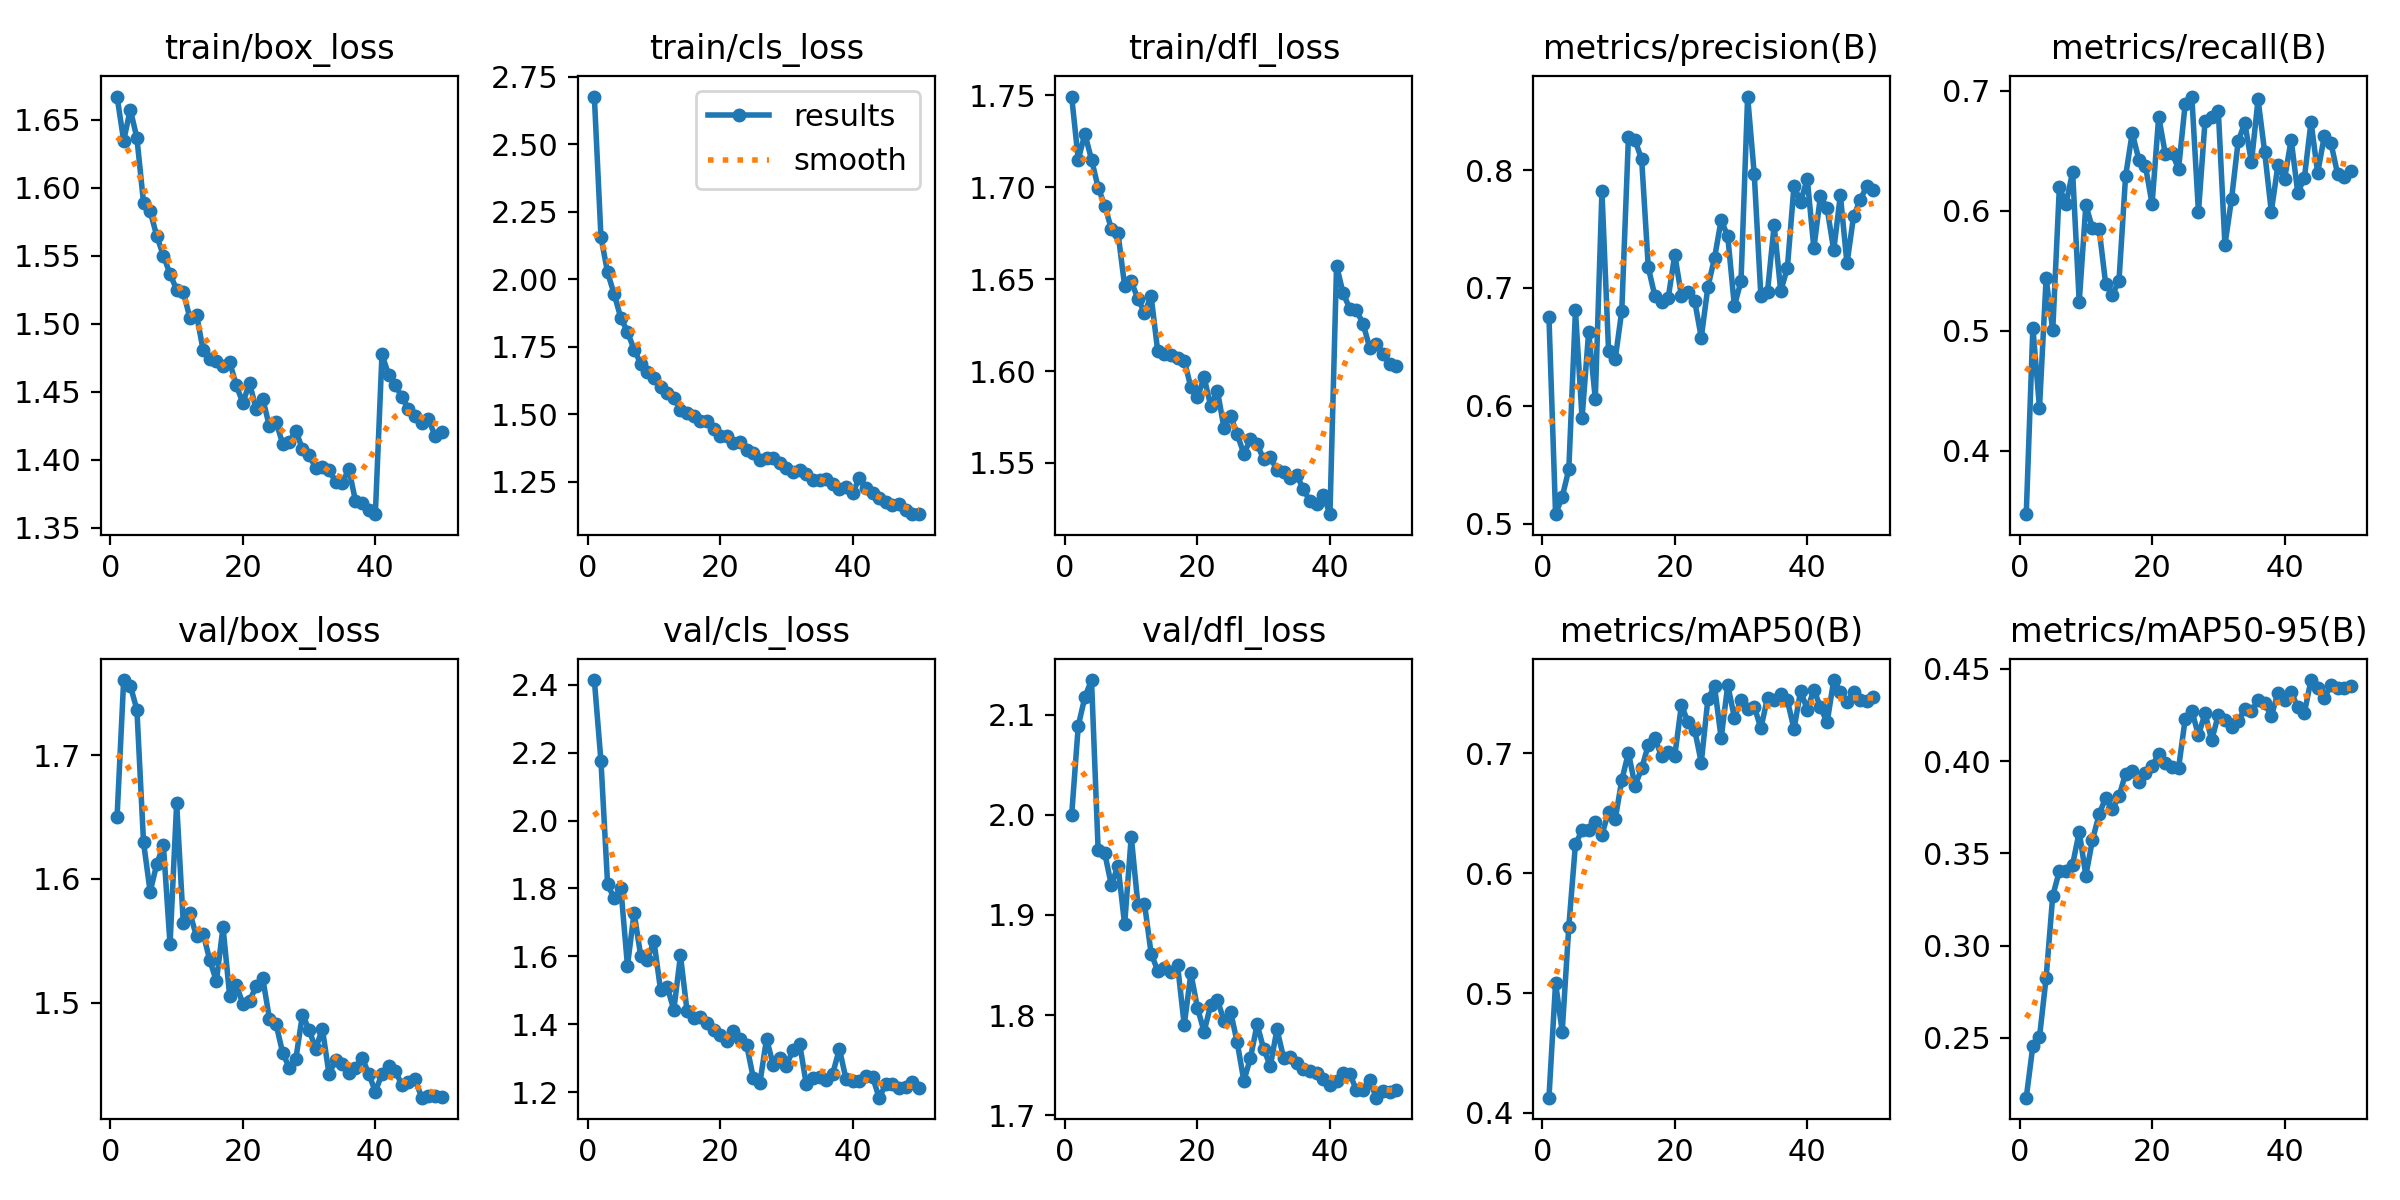

In [20]:
from IPython.display import Image

Image("/kaggle/working/runs/detect/plant_disease_majority/results.png")

In [21]:
model = YOLO("/kaggle/working/runs/detect/plant_disease_majority/weights/best.pt")

results = model.predict(
    source="/kaggle/input/datasets/nandini004aikmckmvji/majority-class-dataset/test/images",
    save=True
)


image 1/794 /kaggle/input/datasets/nandini004aikmckmvji/majority-class-dataset/test/images/Early-Leaf-Spot-818-_jpg.rf.bf70e3ba056b64179ac0a53c1bc83e55.jpg: 640x640 1 groundnut_early_leaf_spot, 8.3ms
image 2/794 /kaggle/input/datasets/nandini004aikmckmvji/majority-class-dataset/test/images/Early-Leaf-Spot-82-_jpg.rf.b9c633574248fe8bf0cbc6fff443b183.jpg: 640x640 (no detections), 7.2ms
image 3/794 /kaggle/input/datasets/nandini004aikmckmvji/majority-class-dataset/test/images/Early-Leaf-Spot-821-_jpg.rf.2cf61613e025aea1c153e85f29cb62c1.jpg: 640x640 1 banana_sigatoka, 7.2ms
image 4/794 /kaggle/input/datasets/nandini004aikmckmvji/majority-class-dataset/test/images/Early-Leaf-Spot-822-_jpg.rf.53c703a2e63a096321bf536e609b6999.jpg: 640x640 1 banana_sigatoka, 7.2ms
image 5/794 /kaggle/input/datasets/nandini004aikmckmvji/majority-class-dataset/test/images/Early-Leaf-Spot-823-_jpg.rf.4f4ca240d721aaccdbbfbf48238dc264.jpg: 640x640 1 banana_sigatoka, 7.2ms
image 6/794 /kaggle/input/datasets/nandini

In [22]:
!ls /kaggle/working/runs/detect/predict

cordana-516-_jpeg.rf.cc7301bf49f939f961861b50f8f2d05f.jpg
cordana-521-_jpeg.rf.93dc1cf4cfcc3dd81eec545bf0a7807c.jpg
cordana-528-_jpeg.rf.9e52ad5201b9155209ad0ca86d65d533.jpg
cordana-529-_jpeg.rf.44b1d3955f606d16548aea17038b0409.jpg
cordana-532-_jpeg.rf.ebb44d3b12e801b22baf290bf4c4eb13.jpg
cordana-533-_jpeg.rf.0dc67d973e3a5c41dbe32c8897e7676f.jpg
cordana-534-_jpeg.rf.aa6a1189fe6fa03d09492e4631caf3ec.jpg
cordana-538-_jpeg.rf.219a454e5b2d3dcd6b39972ff08c931c.jpg
cordana-53-_jpeg.rf.7d44b9dbf4100a91bc721a9513a19f16.jpg
cordana-542-_jpeg.rf.8970bb996b1b031ce5b7dd9a3fda3a74.jpg
cordana-543-_jpeg.rf.9cab97b97373b6cbc8c871d03dcc2c74.jpg
cordana-544-_jpeg.rf.f0363d8c3de9c9cd4867de2df858c036.jpg
cordana-545-_jpeg.rf.349f80f6718b3d93102072b4db530c31.jpg
cordana-547-_jpeg.rf.499317a173a8c25607d42974bdc8fd7c.jpg
cordana-549-_jpeg.rf.4dc5bcea3e19df0c0b6c24c9b2b5fc55.jpg
cordana-551-_jpeg.rf.8b69b8cf93c01cc92f83db6956965979.jpg
cordana-552-_jpeg.rf.7c1c949f9ee38525025379de90e6c153.jpg
cordana-554-_jp


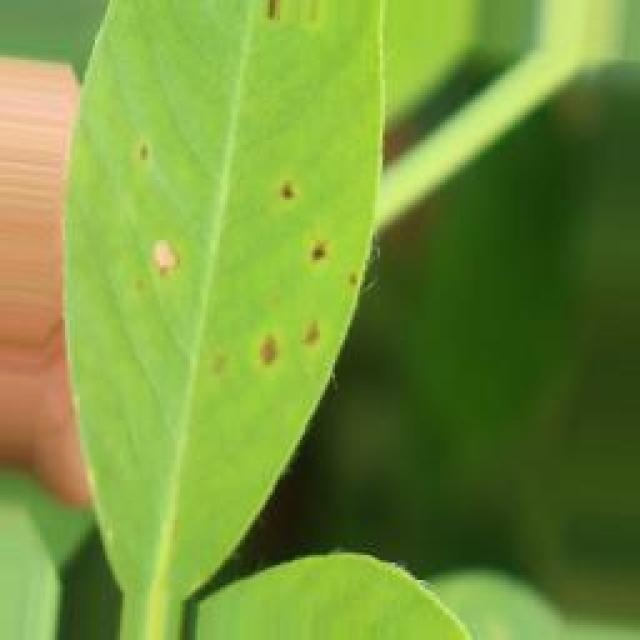
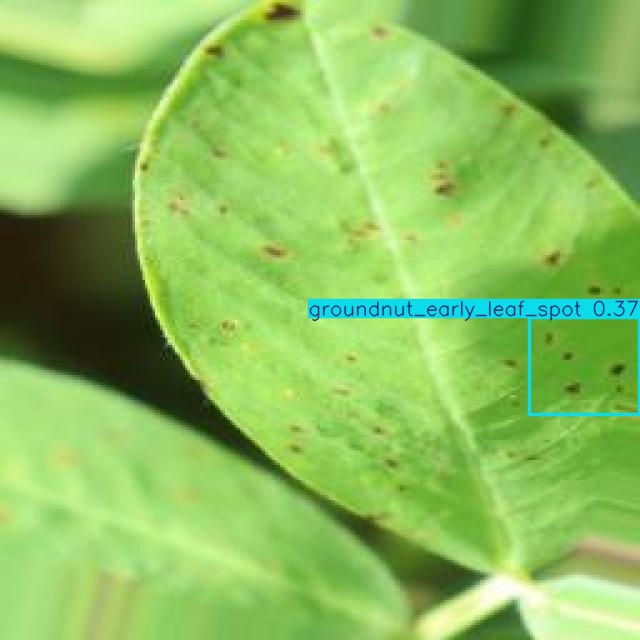
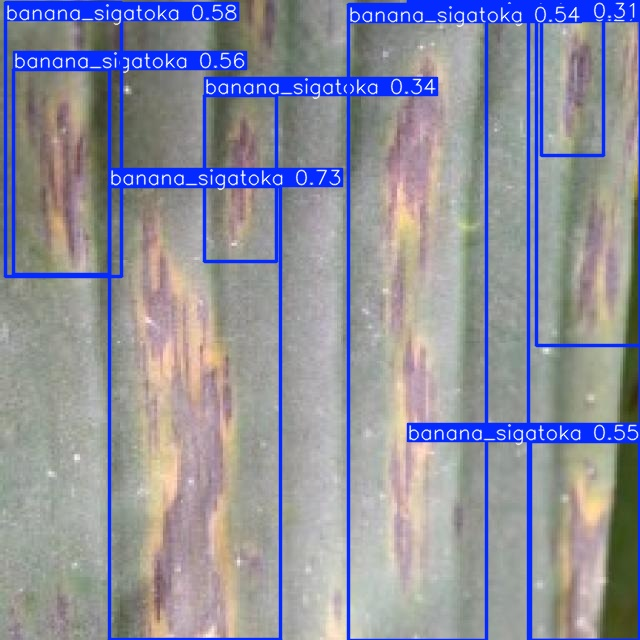
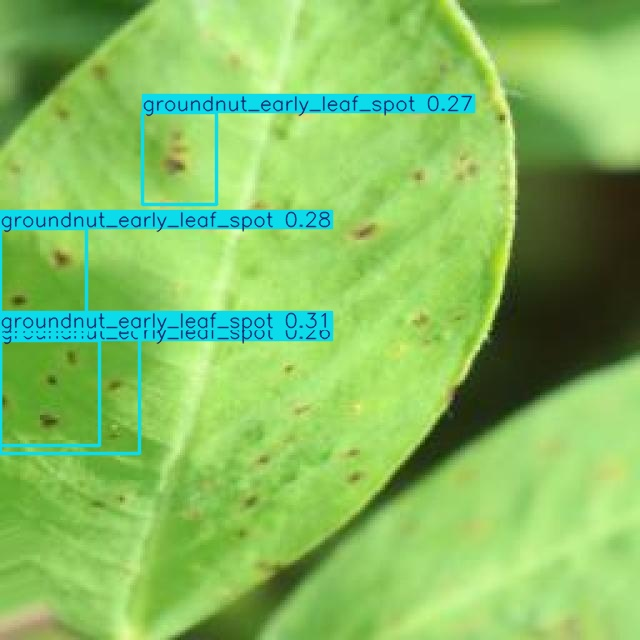
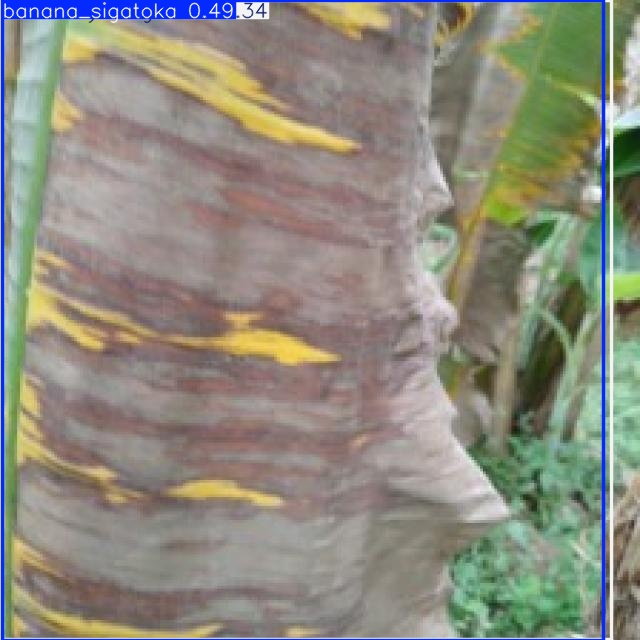
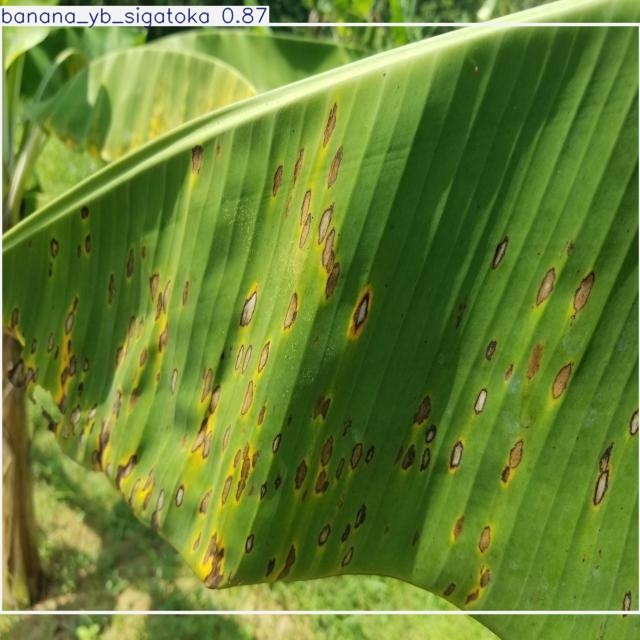
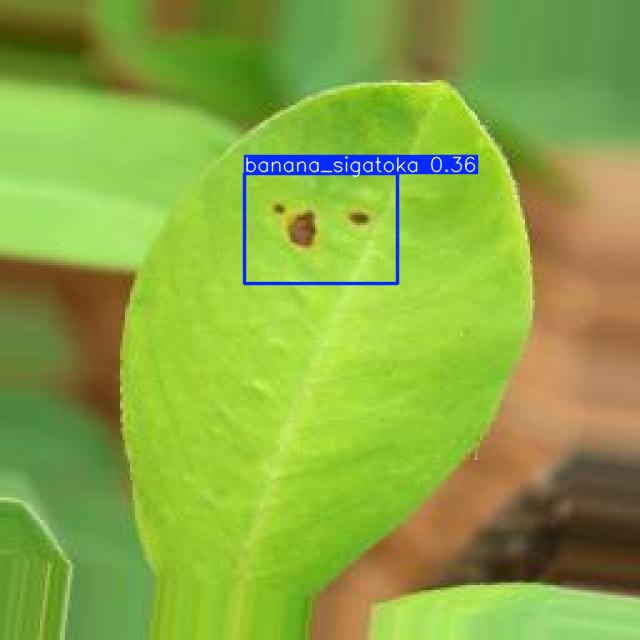
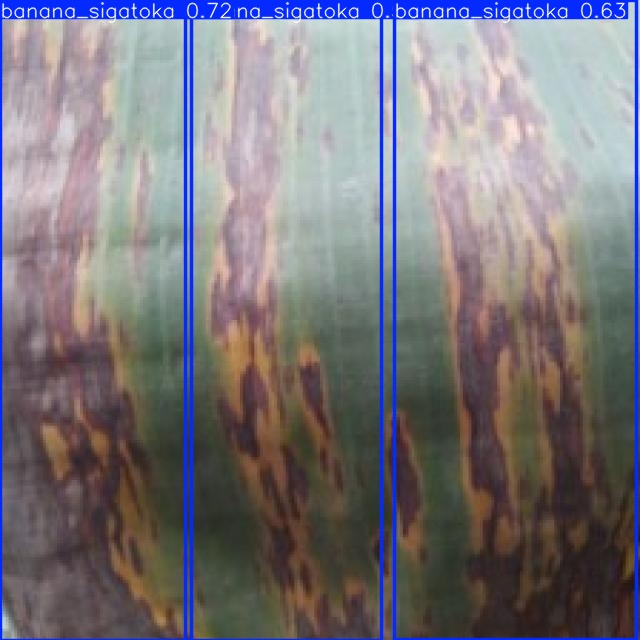
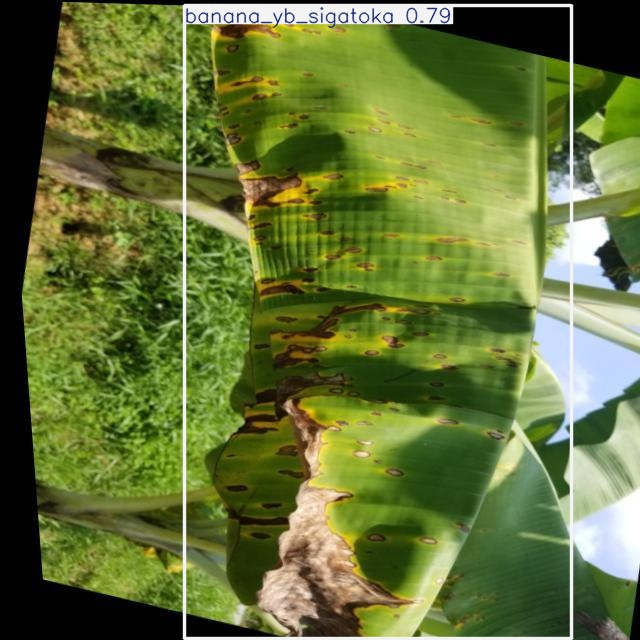
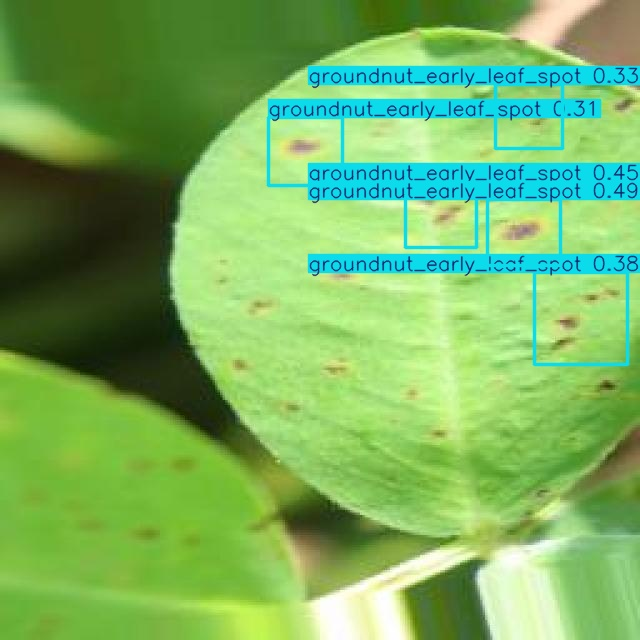
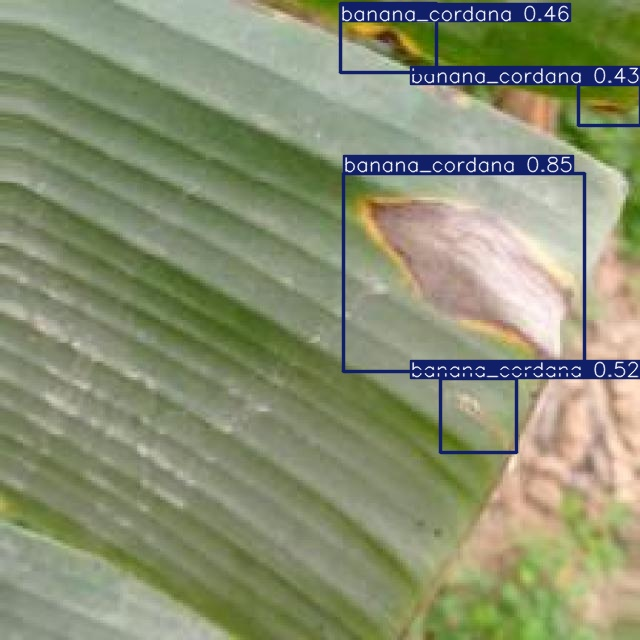
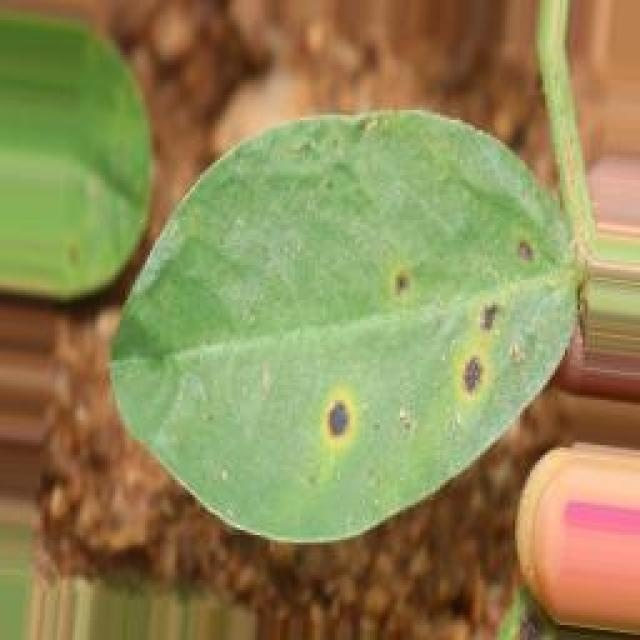

In [24]:
from IPython.display import display, HTML
import os
import base64

folder = "/kaggle/working/runs/detect/predict"
images = os.listdir(folder)[:12]

html = ""

for img in images:
    path = os.path.join(folder, img)
    with open(path, "rb") as f:
        data = base64.b64encode(f.read()).decode()
    html += f'<img src="data:image/jpeg;base64,{data}" width="300" style="margin:5px;">'

display(HTML(html))

In [16]:
model.val()

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 56.8±16.8 MB/s, size: 31.0 KB)
val: Scanning /kaggle/input/datasets/nandini004aikmckmvji/majority-class-dataset/valid/labels... 1580 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1580/1580 1.2Kit/s 1.3s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/nandini004aikmckmvji/majority-class-dataset/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 99/99 7.4it/s 13.4s0.1s
                   all       1580       3700      0.734      0.674      0.762      0.444
       banana_sigatoka        174        865      0.497      0.624      0.588      0.286
groundnut_early_leaf_spot        341       1206      0.815      0.168      0.544      0.193
    banana_yb_sigatoka        558        674      0.742      0.838       0.86      0.577
groundnut_late_leaf_spot

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x789021293020>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

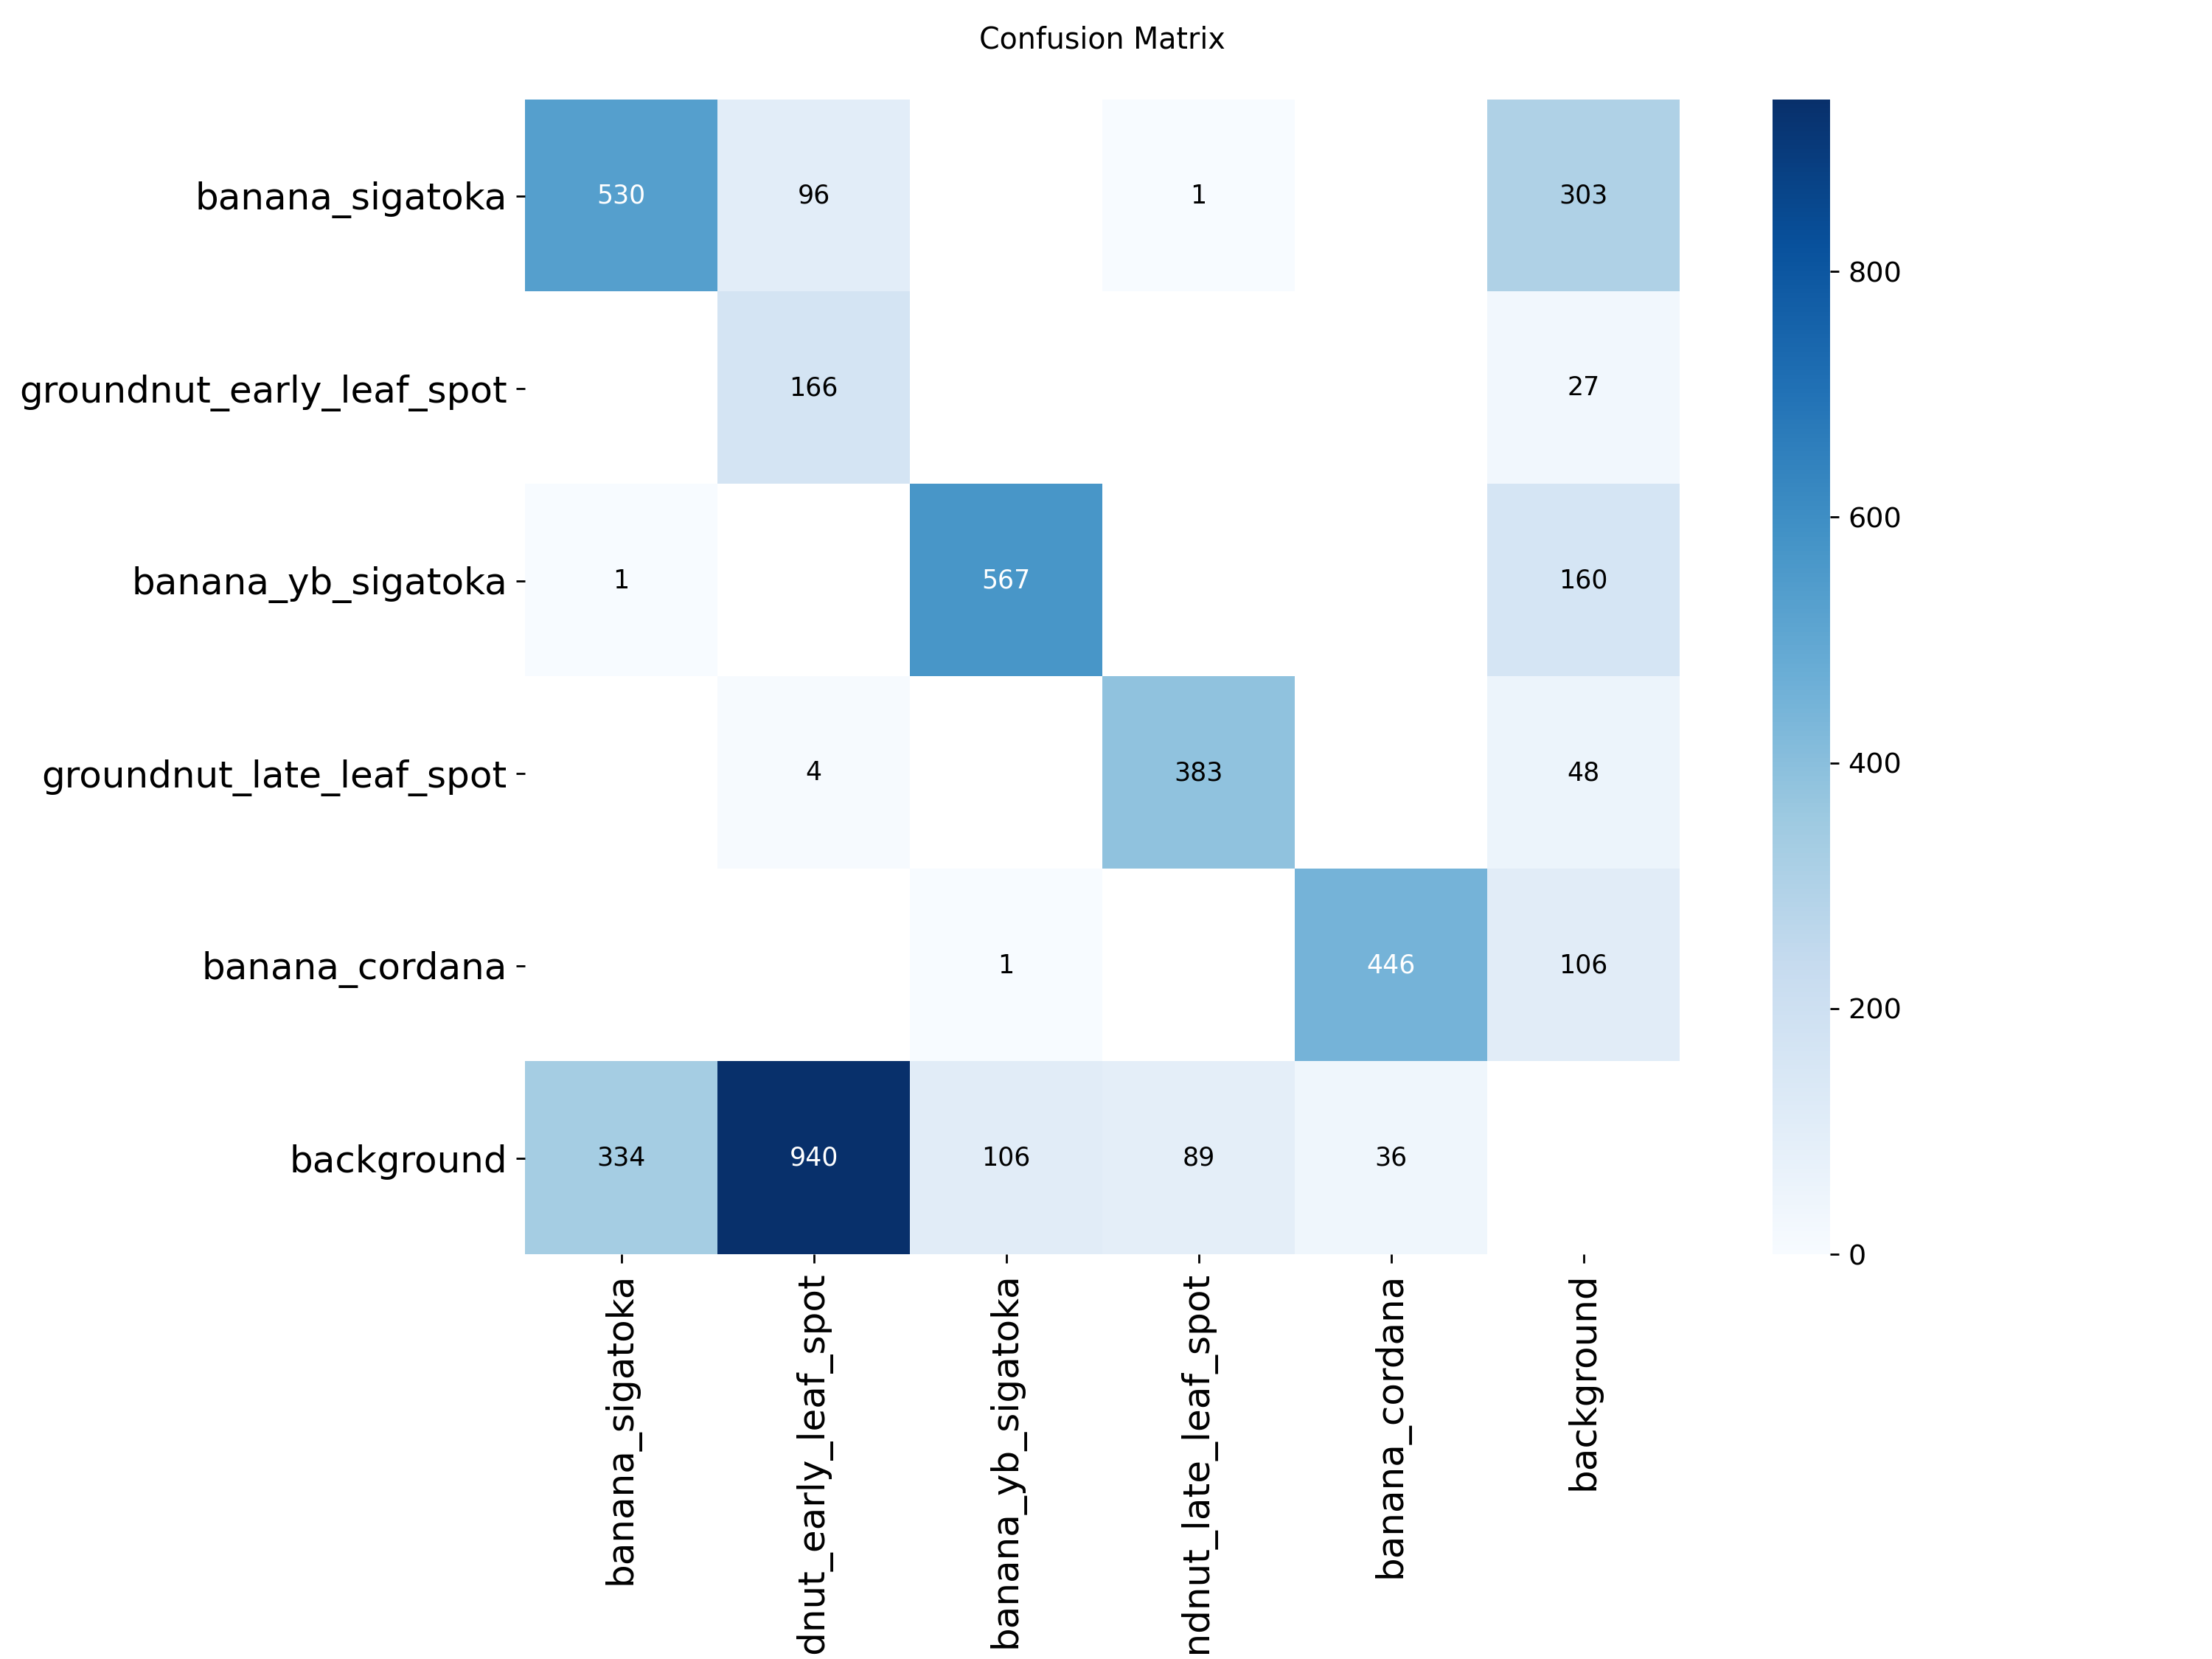

In [25]:
from IPython.display import Image, display

display(Image("/kaggle/working/runs/detect/plant_disease_majority/confusion_matrix.png"))

In [ ]:
!zip -r plant_disease_majority.zip /kaggle/working/runs/detect/plant_disease_majority

In [ ]:
from IPython.display import FileLink
FileLink('/kaggle/working/plant_disease_minority.zip')